In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_context('notebook')
sns.set_style('whitegrid')

In [2]:
prefix = '/home/ines/repositories/'
firing_rates_dir = prefix + 'representation_learning_variability/paper-individuality/data/firing_rates/'

# List available firing rate files (they don't have .pkl extension)
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
print(f"Found {len(pkl_files)} firing rate files:")
for f in pkl_files[:10]:
    print(f"  {f}")
if len(pkl_files) > 10:
    print(f"  ... and {len(pkl_files) - 10} more")

Found 37 firing rate files:
  firing_rate_01864e9d-0dbe-41d4-9e3a-0285348ecfc1
  firing_rate_05ec6af9-6c83-422d-91a3-ba815fa65e92
  firing_rate_0777b1bf-964b-49b7-888b-8a6c9df09c3b
  firing_rate_08ed0b3c-9f94-4c1f-8522-3d42a642a6b0
  firing_rate_0909252c-3ad0-413f-96f5-7eff885b50aa
  firing_rate_117f0d28-3cc0-4837-9e3e-46db5bc3e662
  firing_rate_18be19f9-6ca5-4fc8-9220-ba43c3e75905
  firing_rate_1a60a6e1-da99-4d4e-a734-39b1d4544fad
  firing_rate_298e2a70-9801-45f0-b91c-d6bb9718427e
  firing_rate_43b9b189-5221-46a0-928a-e137bc326534
  ... and 27 more


In [19]:
# Load a single file to explore structure
if pkl_files:
    sample_file = pkl_files[2]
    with open(os.path.join(firing_rates_dir, sample_file), 'rb') as f:
        df = pickle.load(f)
    
    print(f"\nLoaded: {sample_file}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()[:15]}...")
    print(f"\nFirst few rows:")
    print(df.iloc[:3, :8])


Loaded: firing_rate_0777b1bf-964b-49b7-888b-8a6c9df09c3b
Shape: (24339, 98)

Columns: ['pid', 'session', 'neuron_id', 'area', 'trial_id', 'event_time', 'condition', 'n_bins', 't_-0.500', 't_-0.483', 't_-0.466', 't_-0.449', 't_-0.433', 't_-0.416', 't_-0.399']...

First few rows:
                                    pid                               session  \
0  0777b1bf-964b-49b7-888b-8a6c9df09c3b  ee212778-3903-4f5b-ac4b-a72f22debf03   
1  0777b1bf-964b-49b7-888b-8a6c9df09c3b  ee212778-3903-4f5b-ac4b-a72f22debf03   
2  0777b1bf-964b-49b7-888b-8a6c9df09c3b  ee212778-3903-4f5b-ac4b-a72f22debf03   

                  neuron_id  area  trial_id  event_time   condition  n_bins  
0  PAL_neuron_4_spike_count  root       1.0   23.775414  Left_0.125      90  
1  PAL_neuron_4_spike_count  root       2.0   26.647232  Left_0.125      89  
2  PAL_neuron_4_spike_count  root       3.0   32.942268   Left_0.25      90  


In [20]:
# Extract time column names and values
time_cols = [col for col in df.columns if col.startswith('t_')]
time_values = np.array([float(col.split('_')[1]) for col in time_cols])

print(f"Time columns: {len(time_cols)}")
print(f"Time range: {time_values[0]:.3f}s to {time_values[-1]:.3f}s")
print(f"\nMetadata columns:")
meta_cols = [col for col in df.columns if not col.startswith('t_')]
for col in meta_cols:
    print(f"  {col}: {df[col].dtype} (e.g., {df[col].iloc[0]})")

Time columns: 90
Time range: -0.500s to 1.000s

Metadata columns:
  pid: object (e.g., 0777b1bf-964b-49b7-888b-8a6c9df09c3b)
  session: object (e.g., ee212778-3903-4f5b-ac4b-a72f22debf03)
  neuron_id: object (e.g., PAL_neuron_4_spike_count)
  area: object (e.g., root)
  trial_id: float64 (e.g., 1.0)
  event_time: float64 (e.g., 23.77541386757905)
  condition: object (e.g., Left_0.125)
  n_bins: int64 (e.g., 90)


## Plot 1: Mean PSTH by Condition

In [21]:
# Select a neuron with good coverage
neuron_counts = df['neuron_id'].value_counts()
most_common_neuron = neuron_counts.index[0]

neuron_data = df[df['neuron_id'] == most_common_neuron]
print(f"Selected neuron: {most_common_neuron}")
print(f"  Area: {neuron_data['area'].iloc[0]}")
print(f"  Total trials: {len(neuron_data)}")
print(f"  Conditions: {neuron_data['condition'].unique().tolist()}")

Selected neuron: PAL_neuron_4_spike_count
  Area: root
  Total trials: 399
  Conditions: ['Left_0.125', 'Left_0.25', 'Left_0.0625', 'Right_1.0', 'Right_0.125', 'Right_0.0625', 'Left_1.0', 'Right_0.25', 'Right_0.0', 'Left_0.0']


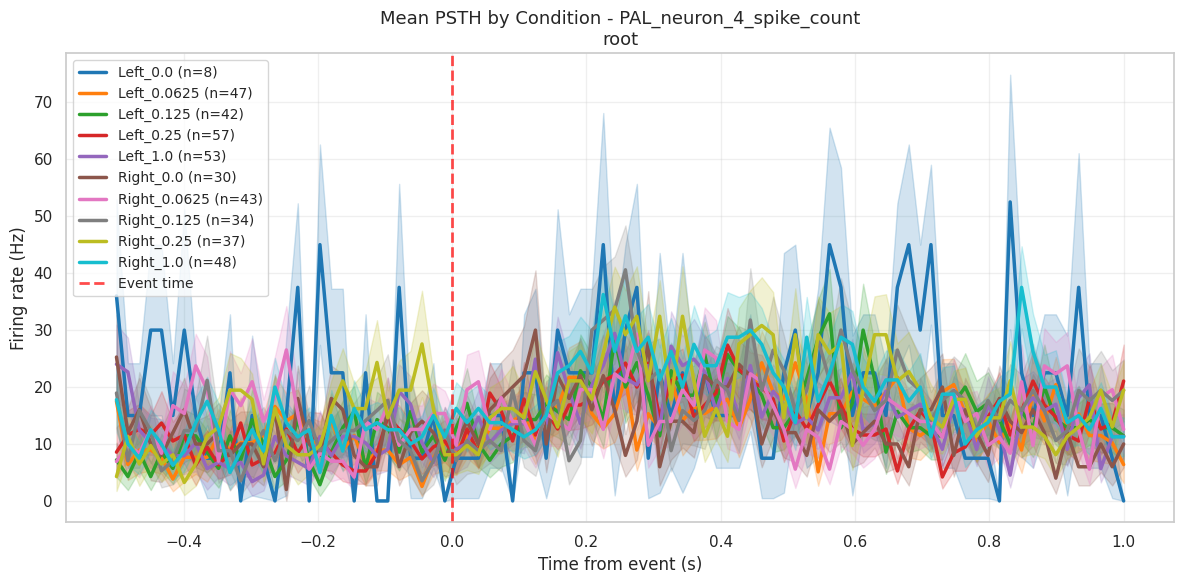

In [22]:
# Plot mean PSTH by condition
fig, ax = plt.subplots(figsize=(12, 6))

conditions = neuron_data['condition'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(conditions)))

for cond_idx, cond in enumerate(sorted(conditions)):
    cond_trials = neuron_data[neuron_data['condition'] == cond]
    
    mean_fr = np.nanmean(cond_trials[time_cols].values, axis=0)
    std_fr = np.nanstd(cond_trials[time_cols].values, axis=0)
    sem_fr = std_fr / np.sqrt(len(cond_trials))
    
    ax.plot(time_values, mean_fr, label=f'{cond} (n={len(cond_trials)})', 
            color=colors[cond_idx], linewidth=2.5)
    ax.fill_between(time_values, mean_fr - sem_fr, mean_fr + sem_fr, 
                    color=colors[cond_idx], alpha=0.2)

ax.axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Event time')
ax.set_xlabel('Time from event (s)', fontsize=12)
ax.set_ylabel('Firing rate (Hz)', fontsize=12)
ax.set_title(f'Mean PSTH by Condition - {most_common_neuron}\n{neuron_data["area"].iloc[0]}', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2: Individual Trial Heatmap

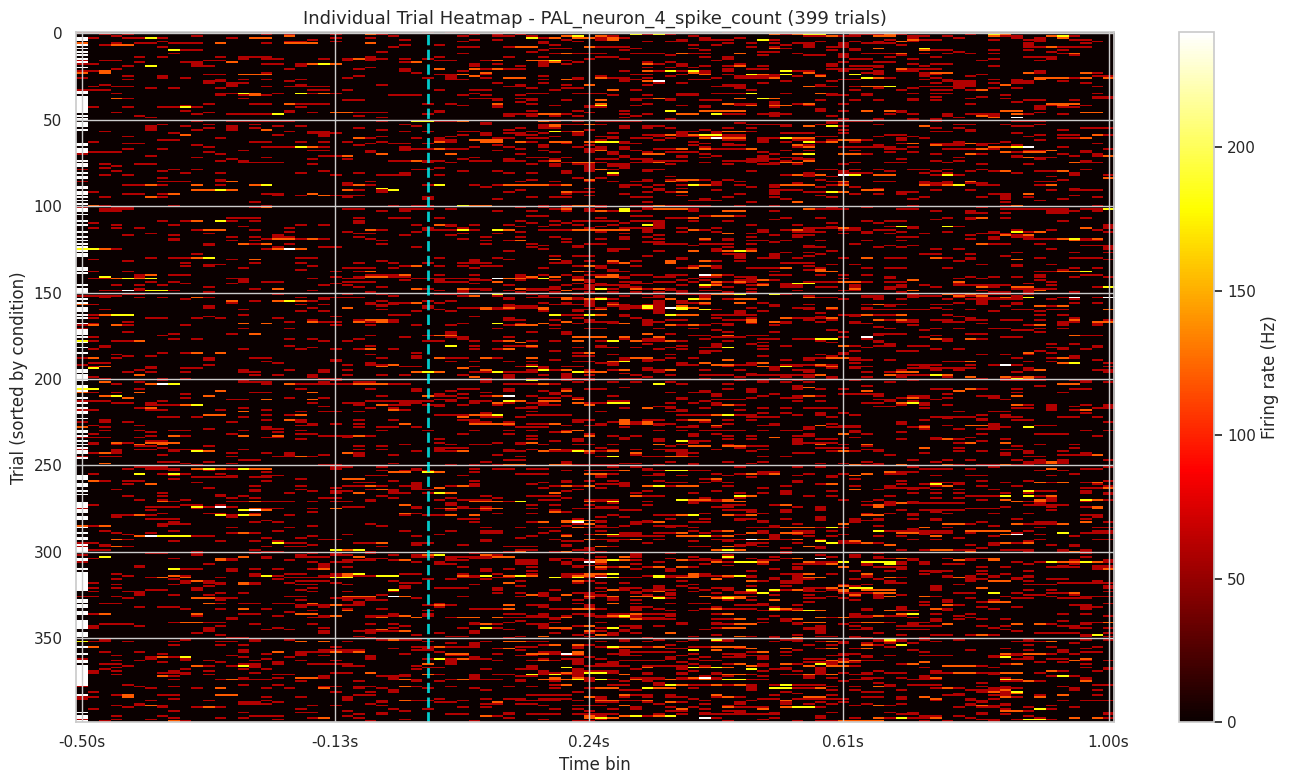

In [23]:
# Heatmap of all trials for this neuron
fr_data = neuron_data[time_cols].values

# Sort trials by condition for better visualization
trial_order = neuron_data['condition'].argsort()
fr_sorted = fr_data[trial_order, :]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(fr_sorted, aspect='auto', cmap='hot', interpolation='nearest')

# Add vertical line at event time
event_idx = np.argmin(np.abs(time_values))
ax.axvline(event_idx, color='cyan', linestyle='--', linewidth=2, alpha=0.8)

ax.set_xlabel('Time bin', fontsize=12)
ax.set_ylabel('Trial (sorted by condition)', fontsize=12)
ax.set_title(f'Individual Trial Heatmap - {most_common_neuron} ({len(neuron_data)} trials)', fontsize=13)
cbar = plt.colorbar(im, ax=ax, label='Firing rate (Hz)')

# Set x-axis ticks to show time
tick_indices = np.linspace(0, len(time_cols)-1, 5, dtype=int)
ax.set_xticks(tick_indices)
ax.set_xticklabels([f'{time_values[i]:.2f}s' for i in tick_indices])

plt.tight_layout()
plt.show()

## Plot 3: Comparison of Top Neurons

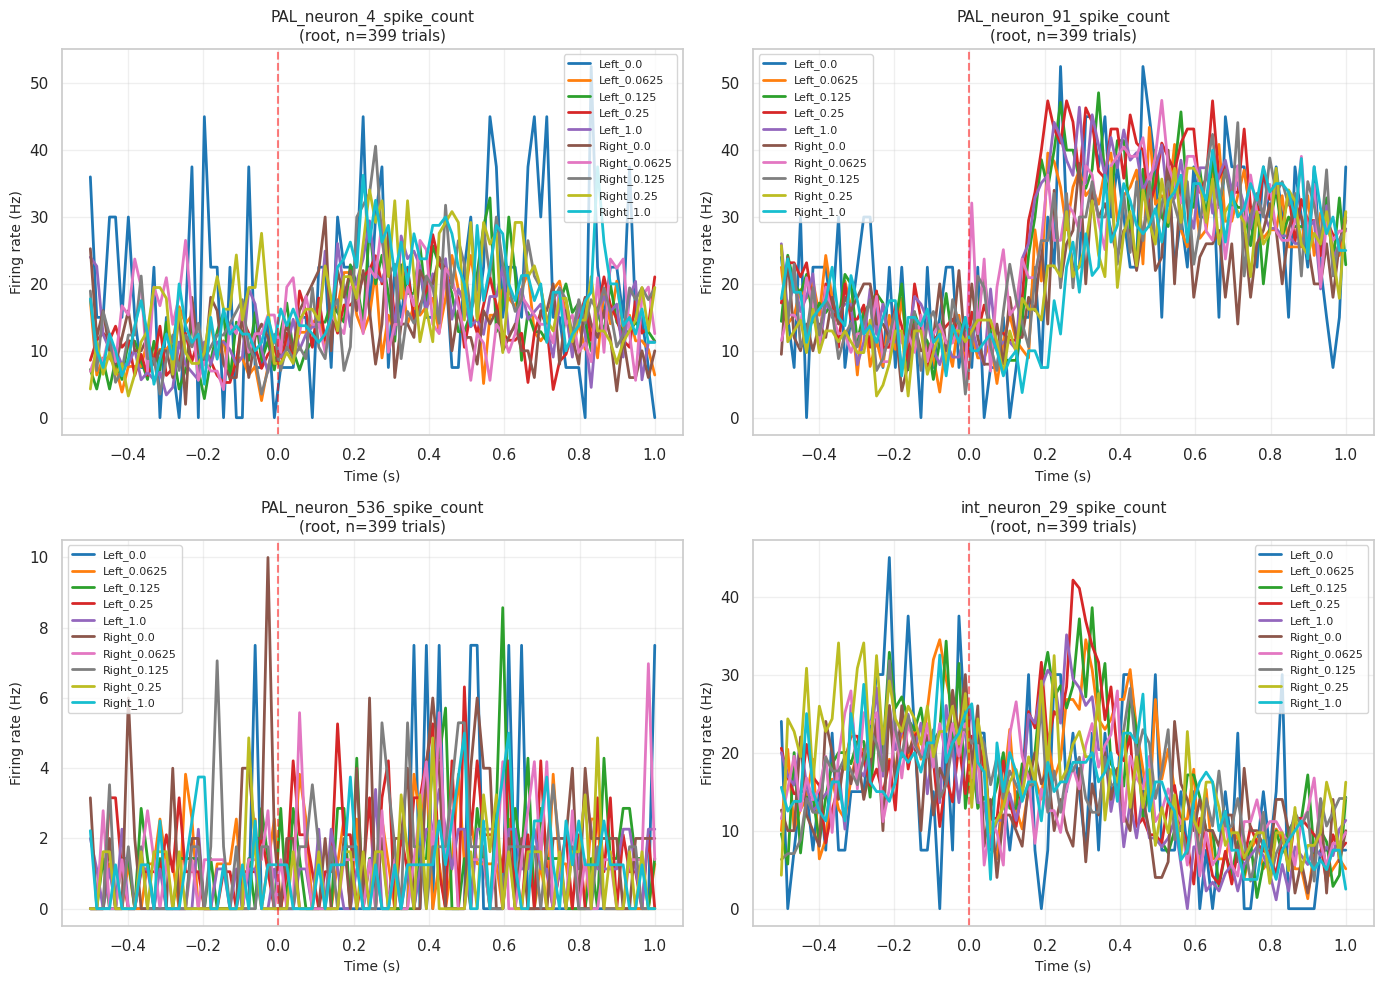

In [24]:
# Get top N neurons by trial count
n_neurons_to_plot = 4
top_neurons = df['neuron_id'].value_counts().head(n_neurons_to_plot).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax_idx, neuron_id in enumerate(top_neurons):
    ax = axes[ax_idx]
    neuron_df = df[df['neuron_id'] == neuron_id]
    
    conditions = sorted(neuron_df['condition'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(conditions)))
    
    for cond_idx, cond in enumerate(conditions):
        cond_trials = neuron_df[neuron_df['condition'] == cond]
        mean_fr = np.nanmean(cond_trials[time_cols].values, axis=0)
        
        ax.plot(time_values, mean_fr, label=f'{cond}', 
                color=colors[cond_idx], linewidth=2)
    
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Firing rate (Hz)', fontsize=10)
    ax.set_title(f'{neuron_id}\n({neuron_df["area"].iloc[0]}, n={len(neuron_df)} trials)', fontsize=11)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot 4: Data Quality Summary

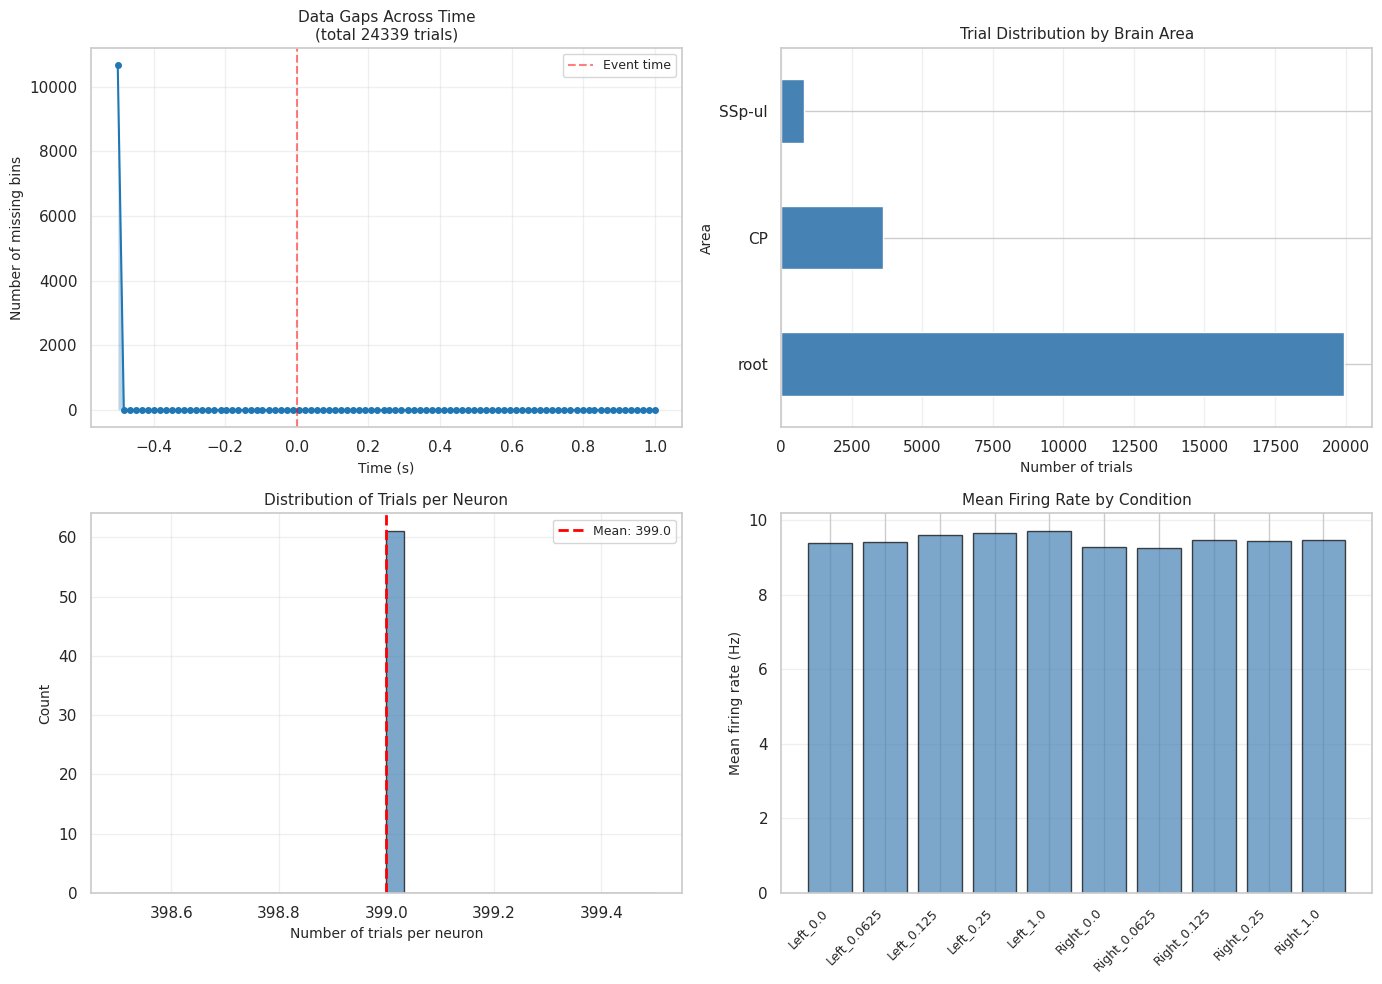


FIRING RATE SUMMARY
File: firing_rate_0777b1bf-964b-49b7-888b-8a6c9df09c3b
Total trials: 24339
Total neurons: 61
Areas: ['root', 'CP', 'SSp-ul']
Conditions: ['Left_0.0', 'Left_0.0625', 'Left_0.125', 'Left_0.25', 'Left_1.0', 'Right_0.0', 'Right_0.0625', 'Right_0.125', 'Right_0.25', 'Right_1.0']

Data completeness: 99.5%
Avg bins per trial: 89.6 / 90 (99.5%)


In [25]:
# Plot data completeness
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. NaN distribution across time
ax = axes[0, 0]
nan_counts = np.sum(np.isnan(df[time_cols].values), axis=0)
ax.plot(time_values, nan_counts, marker='o', markersize=4, linewidth=1.5)
ax.fill_between(time_values, 0, nan_counts, alpha=0.3)
ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Event time')
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Number of missing bins', fontsize=10)
ax.set_title(f'Data Gaps Across Time\n(total {len(df)} trials)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 2. Trial distribution by area
ax = axes[0, 1]
area_counts = df['area'].value_counts()
area_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of trials', fontsize=10)
ax.set_ylabel('Area', fontsize=10)
ax.set_title('Trial Distribution by Brain Area', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# 3. Trials per neuron distribution
ax = axes[1, 0]
trials_per_neuron = df['neuron_id'].value_counts()
ax.hist(trials_per_neuron.values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of trials per neuron', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Distribution of Trials per Neuron', fontsize=11)
ax.axvline(trials_per_neuron.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {trials_per_neuron.mean():.1f}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 4. Firing rate statistics by condition
ax = axes[1, 1]
condition_means = []
conditions = sorted(df['condition'].unique())

for cond in conditions:
    cond_data = df[df['condition'] == cond][time_cols].values
    mean_fr = np.nanmean(cond_data)
    condition_means.append(mean_fr)

bars = ax.bar(range(len(conditions)), condition_means, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean firing rate (Hz)', fontsize=10)
ax.set_title('Mean Firing Rate by Condition', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n" + "="*60)
print(f"FIRING RATE SUMMARY")
print(f"="*60)
print(f"File: {sample_file}")
print(f"Total trials: {len(df)}")
print(f"Total neurons: {df['neuron_id'].nunique()}")
print(f"Areas: {df['area'].unique().tolist()}")
print(f"Conditions: {conditions}")
print(f"\nData completeness: {100 - np.sum(np.isnan(df[time_cols].values)) / df[time_cols].values.size * 100:.1f}%")
print(f"Avg bins per trial: {df['n_bins'].mean():.1f} / 90 ({100*df['n_bins'].mean()/90:.1f}%)")

## Load and Compare Multiple Files

In [26]:
# Load all firing rate files and concatenate
all_dfs = []

for pkl_file in pkl_files[:5]:  # Load first 5 files as example
    try:
        with open(os.path.join(firing_rates_dir, pkl_file), 'rb') as f:
            data = pickle.load(f)
        all_dfs.append(data)
        print(f"Loaded {pkl_file}: {len(data)} trials")
    except Exception as e:
        print(f"Error loading {pkl_file}: {e}")

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\nCombined shape: {combined_df.shape}")
    print(f"Total neurons: {combined_df['neuron_id'].nunique()}")
    print(f"Total sessions: {combined_df['session'].nunique()}")

Loaded firing_rate_01864e9d-0dbe-41d4-9e3a-0285348ecfc1: 57855 trials
Loaded firing_rate_05ec6af9-6c83-422d-91a3-ba815fa65e92: 32718 trials
Loaded firing_rate_0777b1bf-964b-49b7-888b-8a6c9df09c3b: 24339 trials
Loaded firing_rate_08ed0b3c-9f94-4c1f-8522-3d42a642a6b0: 21945 trials
Loaded firing_rate_0909252c-3ad0-413f-96f5-7eff885b50aa: 65037 trials

Combined shape: (201894, 98)
Total neurons: 500
Total sessions: 5


In [ ]:
# Plot correlation
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(valid_data['baseline_fr_mean'], valid_data['lda_1'],
          s=100, alpha=0.6, edgecolors='black')

# Add trend line
z = np.polyfit(valid_data['baseline_fr_mean'], valid_data['lda_1'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(valid_data['baseline_fr_mean'].min(), valid_data['baseline_fr_mean'].max(), 100)
ax.plot(x_line, p_fit(x_line), "r--", alpha=0.8, linewidth=2, label='Linear fit')

ax.set_xlabel('Baseline Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('LDA 1 Score', fontsize=12)
ax.set_title(f'Baseline Firing Rate vs LDA 1 Score\n(r={r_pearson:.3f}, p={p_pearson:.4f}, n={len(valid_data)})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Compute correlations
valid_data = baseline_with_lda[['baseline_fr_mean', 'lda_1']].dropna()

r_pearson, p_pearson = pearsonr(valid_data['baseline_fr_mean'], valid_data['lda_1'])
rho_spearman, p_spearman = spearmanr(valid_data['baseline_fr_mean'], valid_data['lda_1'])

print("\n" + "="*60)
print("CORRELATION: Baseline Firing Rate vs LDA 1")
print("="*60)
print(f"n_samples:      {len(valid_data)}")
print(f"pearson_r:      {r_pearson:.4f}")
print(f"pearson_p:      {p_pearson:.4f}")
print(f"spearman_rho:   {rho_spearman:.4f}")
print(f"spearman_p:     {p_spearman:.4f}")

print("\nInterpretation:")
if p_pearson < 0.05:
    print(f"✓ Significant Pearson correlation (p={p_pearson:.4f})")
else:
    print(f"✗ No significant Pearson correlation (p={p_pearson:.4f})")
    
if p_spearman < 0.05:
    print(f"✓ Significant Spearman correlation (p={p_spearman:.4f})")
else:
    print(f"✗ No significant Spearman correlation (p={p_spearman:.4f})")

In [ ]:
# Load LDA data and merge with baseline
from scipy.stats import pearsonr, spearmanr

data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
lda = pd.read_pickle(data_path + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1', 1: 'lda_2'})

print(f"Loaded LDA: {lda.shape}")
print(f"Columns: {lda.columns.tolist()[:10]}")

# Merge with baseline
baseline_with_lda = session_baseline.merge(
    lda[['session', 'lda_1', 'lda_2']], 
    on='session', 
    how='inner'
)

print(f"\n✓ Merged baseline with LDA: {baseline_with_lda.shape}")
print(baseline_with_lda.head())

In [ ]:
# Calculate baseline firing rate per trial
firing_rates_full['baseline_fr'] = np.nanmean(firing_rates_full[baseline_cols].values, axis=1)

# Aggregate to session level (mean across all neurons)
session_baseline = firing_rates_full.groupby('session').agg({
    'baseline_fr': ['mean', 'std', 'count'],
    'pid': 'first',
    'neuron_id': 'nunique'
}).reset_index()

session_baseline.columns = ['session', 'baseline_fr_mean', 'baseline_fr_std', 'n_trials', 'pid', 'n_neurons']

print(f"Session-level baseline firing rates:")
print(f"Shape: {session_baseline.shape}")
print(session_baseline.head())

In [ ]:
# Extract baseline columns (-0.4s to 0s)
time_cols_full = [col for col in firing_rates_full.columns if col.startswith('t_')]
time_values_full = np.array([float(col.split('_')[1]) for col in time_cols_full])

baseline_mask = (time_values_full >= -0.4) & (time_values_full <= 0.0)
baseline_cols = [col for col, mask in zip(time_cols_full, baseline_mask) if mask]

print(f"Baseline period: -0.4s to 0s")
print(f"Baseline columns: {len(baseline_cols)} bins")
print(f"Time range: {time_values_full[baseline_mask][0]:.3f}s to {time_values_full[baseline_mask][-1]:.3f}s")

In [ ]:
# Load all firing rate files and calculate baseline firing rates
def load_all_firing_rates(firing_rates_dir, max_files=None):
    """Load all firing rate files and concatenate"""
    pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
    if max_files:
        pkl_files = pkl_files[:max_files]

    all_dfs = []
    for i, pkl_file in enumerate(pkl_files):
        try:
            with open(os.path.join(firing_rates_dir, pkl_file), 'rb') as f:
                data = pickle.load(f)
            all_dfs.append(data)
            if (i + 1) % 10 == 0:
                print(f"Loaded {i + 1}/{len(pkl_files)} files...")
        except Exception as e:
            print(f"Error loading {pkl_file}: {e}")

    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    return None

print("Loading all firing rate files...")
firing_rates_full = load_all_firing_rates(firing_rates_dir)
print(f"✓ Loaded: {firing_rates_full.shape}")
print(f"  Sessions: {firing_rates_full['session'].nunique()}")
print(f"  Neurons: {firing_rates_full['neuron_id'].nunique()}")

## Baseline Firing Rate Analysis and LDA 1 Correlation